# Task 7: AutoFeatureSelector Tool
## This task is to test your understanding of various Feature Selection methods outlined in the lecture and the ability to apply this knowledge in a real-world dataset to select best features and also to build an automated feature selection tool as your toolkit

### Use your knowledge of different feature selector methods to build an Automatic Feature Selection tool
- Pearson Correlation
- Chi-Square
- RFE
- Embedded
- Tree (Random Forest)
- Tree (Light GBM)

### Dataset: FIFA 19 Player Skills
#### Attributes: FIFA 2019 players attributes like Age, Nationality, Overall, Potential, Club, Value, Wage, Preferred Foot, International Reputation, Weak Foot, Skill Moves, Work Rate, Position, Jersey Number, Joined, Loaned From, Contract Valid Until, Height, Weight, LS, ST, RS, LW, LF, CF, RF, RW, LAM, CAM, RAM, LM, LCM, CM, RCM, RM, LWB, LDM, CDM, RDM, RWB, LB, LCB, CB, RCB, RB, Crossing, Finishing, Heading, Accuracy, ShortPassing, Volleys, Dribbling, Curve, FKAccuracy, LongPassing, BallControl, Acceleration, SprintSpeed, Agility, Reactions, Balance, ShotPower, Jumping, Stamina, Strength, LongShots, Aggression, Interceptions, Positioning, Vision, Penalties, Composure, Marking, StandingTackle, SlidingTackle, GKDiving, GKHandling, GKKicking, GKPositioning, GKReflexes, and Release Clause.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
from collections import Counter
import math
from scipy import stats

In [2]:
player_df = pd.read_csv("fifa19.csv")

In [3]:
numcols = ['Overall', 'Crossing','Finishing',  'ShortPassing',  'Dribbling','LongPassing', 'BallControl', 'Acceleration','SprintSpeed', 'Agility',  'Stamina','Volleys','FKAccuracy','Reactions','Balance','ShotPower','Strength','LongShots','Aggression','Interceptions']
catcols = ['Preferred Foot','Position','Body Type','Nationality','Weak Foot']

In [4]:
player_df = player_df[numcols+catcols]
player_df.head()

,Overall,Crossing,Finishing,ShortPassing,Dribbling,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,...,ShotPower,Strength,LongShots,Aggression,Interceptions,Preferred Foot,Position,Body Type,Nationality,Weak Foot
0,94,84.0,95.0,90.0,97.0,87.0,96.0,91.0,86.0,91.0,...,85.0,59.0,94.0,48.0,22.0,Left,RF,Messi,Argentina,4.0
1,94,84.0,94.0,81.0,88.0,77.0,94.0,89.0,91.0,87.0,...,95.0,79.0,93.0,63.0,29.0,Right,ST,C. Ronaldo,Portugal,4.0
2,92,79.0,87.0,84.0,96.0,78.0,95.0,94.0,90.0,96.0,...,80.0,49.0,82.0,56.0,36.0,Right,LW,Neymar,Brazil,5.0
3,91,17.0,13.0,50.0,18.0,51.0,42.0,57.0,58.0,60.0,...,31.0,64.0,12.0,38.0,30.0,Right,GK,Lean,Spain,3.0
4,91,93.0,82.0,92.0,86.0,91.0,91.0,78.0,76.0,79.0,...,91.0,75.0,91.0,76.0,61.0,Right,RCM,Normal,Belgium,5.0


In [5]:
player_df = player_df[numcols+catcols]
traindf = pd.concat([player_df[numcols], pd.get_dummies(player_df[catcols])],axis=1)
features = traindf.columns


In [6]:
traindf = pd.concat([player_df[numcols], pd.get_dummies(player_df[catcols])],axis=1)
features = traindf.columns

traindf = traindf.dropna()

In [7]:
traindf = pd.DataFrame(traindf,columns=features)

In [8]:
y = traindf['Overall']>=87
X = traindf.copy()
del X['Overall']

In [9]:
X.head()

,Crossing,Finishing,ShortPassing,Dribbling,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Stamina,...,Nationality_Uganda,Nationality_Ukraine,Nationality_United Arab Emirates,Nationality_United States,Nationality_Uruguay,Nationality_Uzbekistan,Nationality_Venezuela,Nationality_Wales,Nationality_Zambia,Nationality_Zimbabwe
0,84.0,95.0,90.0,97.0,87.0,96.0,91.0,86.0,91.0,72.0,...,False,False,False,False,False,False,False,False,False,False
1,84.0,94.0,81.0,88.0,77.0,94.0,89.0,91.0,87.0,88.0,...,False,False,False,False,False,False,False,False,False,False
2,79.0,87.0,84.0,96.0,78.0,95.0,94.0,90.0,96.0,81.0,...,False,False,False,False,False,False,False,False,False,False
3,17.0,13.0,50.0,18.0,51.0,42.0,57.0,58.0,60.0,43.0,...,False,False,False,False,False,False,False,False,False,False
4,93.0,82.0,92.0,86.0,91.0,91.0,78.0,76.0,79.0,90.0,...,False,False,False,False,False,False,False,False,False,False


In [10]:
len(X.columns)

223

### Set some fixed set of features

In [11]:
feature_name = list(X.columns)
# no of maximum features we need to select
num_feats=30

## Filter Feature Selection - Pearson Correlation

### Pearson Correlation function

In [12]:
# def cor_selector_mine(X, y, num_features):
#     # Your code goes here (Multiple lines)
#     corr_list= []

#     # calculating the correlation of each feature with respect to y
#     # using numpy method
#     for column in X.columns:
#         corr= np.corrcoef(X[column], y)[0][1]
#         # the corrcoef function will bring a 2x2 corr matrix
#         # in this case, so I pick the first value presenting the 
#         # corr of the feature with respect to the target 
#         # ([0][1], but could be [1][0] as well)
        
#         corr_list.append({
#             column: abs(float(corr)) if corr is not np.nan else 0
#         })

#     # sort based on the dictionary values 
#     sorted_corr= sorted(
#         corr_list
#         , key= lambda x: abs(list(x.values())[0]) # sorting based on corr_list VALUES
#     )
#     # in the function above we use abs because for Pearson the most important thing is the magnitude of the correlation

#     # picking only the first num_features (from the end, since our list is already sorted) 
#     final_select= sorted_corr[-num_features:]

#     # Your code ends here
#     return final_select,corr_support
#     #return sorted_corr

In [13]:
def corr_selector(X, y,num_feats):
    # Your code goes here (Multiple lines)
    cor_list= []
    feature_name= X.columns.tolist()

    # calculate the correlation with y for each feature
    for i in X.columns.tolist():
        corr= np.corrcoef(X[i], y)[0][1]
        cor_list.append(corr)

    # replace NaN with 0
    corr_list= [0 if np.isnan(i) else i for i in cor_list]

    # feature name
    corr_feature = X.iloc[:, np.argsort(np.abs(corr_list))[-num_feats:]].columns.tolist()
    
    # feature selection? (0 for not select, 1 for select)
    corr_support= [True if i in corr_feature else False for i in feature_name]
    # Your code ends here
    return corr_support, corr_feature

In [14]:
corr_support, corr_feature = corr_selector(X, y,num_feats)
print(str(len(corr_feature)), 'selected features')

30 selected features


### List the selected features from Pearson Correlation

In [15]:
corr_feature

['Nationality_Costa Rica',
 'Position_LAM',
 'Nationality_Uruguay',
 'Acceleration',
 'SprintSpeed',
 'Strength',
 'Nationality_Gabon',
 'Nationality_Slovenia',
 'Stamina',
 'Weak Foot',
 'Agility',
 'Crossing',
 'Nationality_Belgium',
 'Dribbling',
 'ShotPower',
 'LongShots',
 'Finishing',
 'BallControl',
 'FKAccuracy',
 'LongPassing',
 'Volleys',
 'ShortPassing',
 'Position_RF',
 'Position_LF',
 'Body Type_PLAYER_BODY_TYPE_25',
 'Body Type_Courtois',
 'Body Type_Neymar',
 'Body Type_Messi',
 'Body Type_C. Ronaldo',
 'Reactions']

## Filter Feature Selection - Chi-Sqaure

In [16]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

### Chi-Squared Selector function
- This algorithm will return the most probably related features comparing their statistical association
- Basically the algorithm goes into the dataset and checks how different the target observed values are (related to one feature)
than the target expected values would be if there were no relationship at all
- It goes on each of those features and performs the computations, extracting in the end the ones with highest chi2 scores
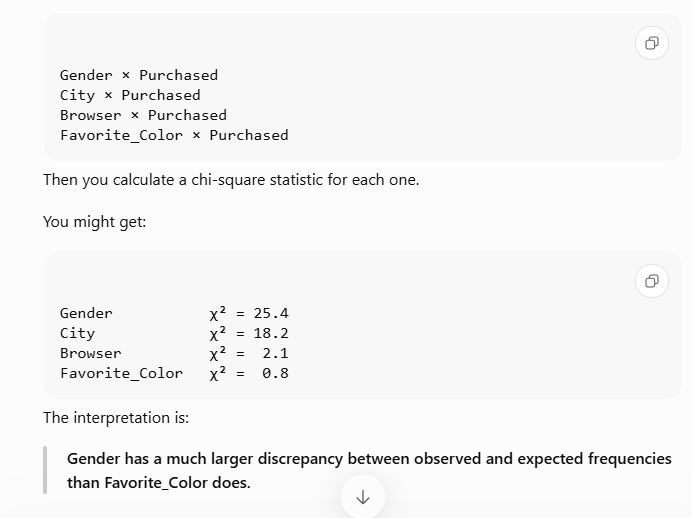 

In [17]:
def chi_squared_selector(X, y, num_feats):
    # Your code goes here (Multiple lines)
    from sklearn.feature_selection import SelectKBest, chi2
    from sklearn.preprocessing import MinMaxScaler

    X_norm= MinMaxScaler().fit_transform(X)

    chi2_selector= SelectKBest(chi2, k= num_feats)
    chi2_selector.fit(X_norm, y) 
    chi2_support= chi2_selector.get_support()
    chi2_feature= X.loc[:, chi2_support].columns.tolist() 
    # Your code ends here
    return chi2_support, chi2_feature

In [18]:
chi2_support, chi2_feature = chi_squared_selector(X, y,num_feats)
print(str(len(chi2_feature)), 'selected features')

30 selected features


### List the selected features from Chi-Square 

In [19]:
chi2_feature

['Finishing',
 'ShortPassing',
 'LongPassing',
 'BallControl',
 'Volleys',
 'FKAccuracy',
 'Reactions',
 'LongShots',
 'Position_CM',
 'Position_LAM',
 'Position_LF',
 'Position_LW',
 'Position_RB',
 'Position_RF',
 'Body Type_C. Ronaldo',
 'Body Type_Courtois',
 'Body Type_Messi',
 'Body Type_Neymar',
 'Body Type_PLAYER_BODY_TYPE_25',
 'Nationality_Belgium',
 'Nationality_Costa Rica',
 'Nationality_Croatia',
 'Nationality_Egypt',
 'Nationality_England',
 'Nationality_France',
 'Nationality_Gabon',
 'Nationality_Slovakia',
 'Nationality_Slovenia',
 'Nationality_Spain',
 'Nationality_Uruguay']

## Wrapper Feature Selection - Recursive Feature Elimination
- These are called a *wrapper* feature selection algorithm because it actually selects the best set of features based on model's accuracy
- They keep re-testing until they find the combination set of features with the best measured accuracy
- One interesting part on all of this is that the wrapper can be any model as needed (so if we're dealing with a pure regression dataset 
we can use a LinearRegression model... pure classification we can use LogisticRegression... and so on so forth) 
    - So it depends on the use case... On each use case it will use the best metrics to find the best set of feature accordingly

In [20]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

### RFE Selector function

In [21]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

In [22]:
def rfe_selector(X, y, num_feats):
    # Your code goes here (Multiple lines)

    rfe_selector= RFE(
        estimator= LogisticRegression(),
        n_features_to_select= num_feats,
        step= 10,
        verbose= 5
    )

    X_norm= MinMaxScaler().fit_transform(X)
    rfe_selector.fit(X_norm, y)

    rfe_support= rfe_selector.get_support()
    rfe_feature= X.loc[:, rfe_support].columns.tolist()
    # Your code ends here
    return rfe_support, rfe_feature

In [23]:
rfe_support, rfe_feature = rfe_selector(X, y,num_feats)
print(str(len(rfe_feature)), 'selected features')

Fitting estimator with 223 features.
Fitting estimator with 213 features.
Fitting estimator with 203 features.
Fitting estimator with 193 features.
Fitting estimator with 183 features.
Fitting estimator with 173 features.
Fitting estimator with 163 features.
Fitting estimator with 153 features.
Fitting estimator with 143 features.
Fitting estimator with 133 features.
Fitting estimator with 123 features.
Fitting estimator with 113 features.
Fitting estimator with 103 features.
Fitting estimator with 93 features.
Fitting estimator with 83 features.
Fitting estimator with 73 features.
Fitting estimator with 63 features.
Fitting estimator with 53 features.
Fitting estimator with 43 features.
Fitting estimator with 33 features.
30 selected features


### List the selected features from RFE

In [24]:
rfe_feature

['Finishing',
 'ShortPassing',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Volleys',
 'Reactions',
 'Strength',
 'Weak Foot',
 'Position_CB',
 'Position_CM',
 'Position_GK',
 'Position_LCB',
 'Position_LM',
 'Position_LW',
 'Position_RB',
 'Position_RCB',
 'Position_RW',
 'Body Type_Lean',
 'Nationality_Belgium',
 'Nationality_Costa Rica',
 'Nationality_Croatia',
 'Nationality_Gabon',
 'Nationality_Netherlands',
 'Nationality_Slovakia',
 'Nationality_Slovenia',
 'Nationality_Uruguay',
 'Nationality_Wales']

## Embedded Selection - Lasso: SelectFromModel
- LASSO tries to make predictions while "charging" the model for having coefficients. Features that aren't contributing enough can have their coefficient driven all the way to zero, therefore resulting in a feature selection

- Just a few observations about Lasso:
    - Normally we apply it as out final model already (it's a linear regression as well, but traiend with penalty)
    - Or we can also use it to select features (as we are doing irght now), and then on those features we can apply the LinearRegression algorithm

In [25]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

In [26]:
def embedded_log_reg_selector(X, y, num_feats):
    # Your code goes here (Multiple lines)
    X_norm= MinMaxScaler().fit_transform(X)

    lr_selector= SelectFromModel(
        LogisticRegression(l1_ratio= 1, solver= 'liblinear'),
        max_features= num_feats
        )
    lr_selector.fit(X_norm,y)

    lr_support= lr_selector.get_support()
    lr_feature= X.loc[:, lr_support].columns.tolist()

    # Your code ends here
    return lr_support, lr_feature

In [27]:
embedded_lr_support, embedded_lr_feature = embedded_log_reg_selector(X, y, num_feats)
print(str(len(embedded_lr_feature)), 'selected features')

27 selected features


In [28]:
embedded_lr_feature

['LongPassing',
 'Reactions',
 'Balance',
 'Aggression',
 'Preferred Foot_Right',
 'Position_CAM',
 'Position_CM',
 'Position_GK',
 'Position_LCB',
 'Position_LM',
 'Position_LW',
 'Position_RB',
 'Position_RCB',
 'Position_RW',
 'Body Type_Lean',
 'Body Type_Stocky',
 'Nationality_Belgium',
 'Nationality_Brazil',
 'Nationality_Croatia',
 'Nationality_England',
 'Nationality_France',
 'Nationality_Germany',
 'Nationality_Italy',
 'Nationality_Netherlands',
 'Nationality_Portugal',
 'Nationality_Slovenia',
 'Nationality_Uruguay']

## Tree based(Random Forest): SelectFromModel

In [29]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

In [30]:
def embedded_rf_selector(X, y, num_feats):
    # Your code goes here (Multiple lines)
    embedded_rf_selector= SelectFromModel(
        RandomForestClassifier(n_estimators= 100),
        max_features= num_feats
    )
    embedded_rf_selector.fit(X,y)

    embedded_rf_support = embedded_rf_selector.get_support()
    embedded_rf_feature = X.loc[:, embedded_rf_support].columns.tolist()
    # Your code ends here
    return embedded_rf_support, embedded_rf_feature

In [31]:
embedded_rf_support, embedded_rf_feature = embedded_rf_selector(X, y, num_feats)
print(str(len(embedded_rf_feature)), 'selected features')

25 selected features


In [32]:
embedded_rf_feature

['Crossing',
 'Finishing',
 'ShortPassing',
 'Dribbling',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Stamina',
 'Volleys',
 'FKAccuracy',
 'Reactions',
 'Balance',
 'ShotPower',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Weak Foot',
 'Body Type_Courtois',
 'Body Type_Lean',
 'Body Type_Normal',
 'Nationality_Italy',
 'Nationality_Slovenia']

## Tree based(Light GBM): SelectFromModel

In [33]:
from sklearn.feature_selection import SelectFromModel
from lightgbm import LGBMClassifier

In [34]:
def embedded_lgbm_selector(X, y, num_feats):
    # Your code goes here (Multiple lines)
    lgbmc= LGBMClassifier(
        n_estimators= 500,
        learning_rate= 0.05,
        num_leaves= 32,
        colsample_bytree=0.2,
        reg_alpha=3,
        reg_lambda=1,
        min_split_gain= 0.01,
        min_child_weight=40
    )

    embedded_lgbm_selector= SelectFromModel(lgbmc
                                           , max_features= num_feats
                                        )
    embedded_lgbm_selector.fit(X,y)

    embedded_lgbm_support= embedded_lgbm_selector.get_support()
    embedded_lgbm_feature= X.loc[:, embedded_lgbm_support].columns.tolist()
    # Your code ends here

    return embedded_lgbm_support, embedded_lgbm_feature

In [35]:
embedded_lgbm_support, embedded_lgbm_feature = embedded_lgbm_selector(X, y, num_feats)
print(str(len(embedded_lgbm_feature)), 'selected features')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 55, number of negative: 18104
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000693 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1812
[LightGBM] [Info] Number of data points in the train set: 18159, number of used features: 124
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.003029 -> initscore=-5.796555
[LightGBM] [Info] Start training from score -5.796555
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [36]:
embedded_lgbm_feature

['Crossing',
 'Finishing',
 'ShortPassing',
 'Dribbling',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Stamina',
 'Volleys',
 'FKAccuracy',
 'Reactions',
 'Balance',
 'ShotPower',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Weak Foot',
 'Preferred Foot_Left',
 'Preferred Foot_Right',
 'Position_CAM',
 'Position_CB',
 'Position_CDM',
 'Position_CF',
 'Position_CM',
 'Position_GK',
 'Position_LAM',
 'Position_LB']

## Putting all of it together: AutoFeatureSelector Tool

In [37]:
pd.set_option('display.max_rows', None)
# put all selection together
feature_selection_df = pd.DataFrame({'Feature':feature_name, 'Pearson':corr_support, 'Chi-2':chi2_support, 'RFE':rfe_support, 'Logistics':embedded_lr_support,
                                    'Random Forest':embedded_rf_support, 'LightGBM':embedded_lgbm_support})
# count the selected times for each feature
feature_selection_df['Total'] = feature_selection_df.drop(columns='Feature').sum(axis=1)

# display the top 100
feature_selection_df = feature_selection_df.sort_values(['Total','Feature'] , ascending=False)
feature_selection_df.index = range(1, len(feature_selection_df)+1)
feature_selection_df.head(num_feats)

,Feature,Pearson,Chi-2,RFE,Logistics,Random Forest,LightGBM,Total
1,Reactions,True,True,True,True,True,True,6
2,LongPassing,True,True,True,True,True,True,6
3,Volleys,True,True,True,False,True,True,5
4,ShortPassing,True,True,True,False,True,True,5
5,Nationality_Slovenia,True,True,True,True,True,False,5
6,Finishing,True,True,True,False,True,True,5
7,BallControl,True,True,True,False,True,True,5
8,Weak Foot,True,False,True,False,True,True,4
9,Strength,True,False,True,False,True,True,4
10,SprintSpeed,True,False,True,False,True,True,4


In [38]:
feature_selection_df.iloc[:5]['Feature'].tolist()

['Reactions', 'LongPassing', 'Volleys', 'ShortPassing', 'Nationality_Slovenia']

## Can you build a Python script that takes dataset and a list of different feature selection methods that you want to try and output the best (maximum votes) features from all methods?

In [39]:
def preprocess_dataset(dataset_path):
    # Your code starts here (Multiple lines)
    player_df= pd.read_csv(f'{dataset_path}')

    numcols = ['Overall', 'Crossing','Finishing',  'ShortPassing',  'Dribbling','LongPassing', 'BallControl', 'Acceleration','SprintSpeed', 'Agility',  'Stamina','Volleys','FKAccuracy','Reactions','Balance','ShotPower','Strength','LongShots','Aggression','Interceptions']
    catcols = ['Preferred Foot','Position','Body Type','Nationality','Weak Foot']
    player_df = player_df[numcols+catcols]

    player_df = player_df[numcols+catcols]
    traindf = pd.concat([player_df[numcols], pd.get_dummies(player_df[catcols])],axis=1)
    features = traindf.columns

    traindf = pd.concat([player_df[numcols], pd.get_dummies(player_df[catcols])],axis=1)
    features = traindf.columns

    traindf = traindf.dropna()

    traindf = pd.DataFrame(traindf,columns=features)

    y = traindf['Overall']>=87
    X = traindf.copy()
    del X['Overall']

    num_feats=30
    
    # Your code ends here
    return X, y, num_feats

In [40]:
def autoFeatureSelector(dataset_path, methods=[]):
    # Parameters
    # data - dataset to be analyzed (csv file)
    # methods - various feature selection methods we outlined before, use them all here (list)
    
    # preprocessing
    X, y, num_feats = preprocess_dataset(dataset_path)
    
    # Run every method we outlined above from the methods list and collect returned best features from every method
    if 'pearson' in methods:
        cor_support, cor_feature = corr_selector(X, y,num_feats)
    if 'chi-square' in methods:
        chi_support, chi_feature = chi_squared_selector(X, y,num_feats)
    if 'rfe' in methods:
        rfe_support, rfe_feature = rfe_selector(X, y,num_feats)
    if 'log-reg' in methods:
        embedded_lr_support, embedded_lr_feature = embedded_log_reg_selector(X, y, num_feats)
    if 'rf' in methods:
        embedded_rf_support, embedded_rf_feature = embedded_rf_selector(X, y, num_feats)
    if 'lgbm' in methods:
        embedded_lgbm_support, embedded_lgbm_feature = embedded_lgbm_selector(X, y, num_feats)
    
    
    # Combine all the above feature list and count the maximum set of features that got selected by all methods
    #### Your Code starts here (Multiple lines)
    
    pd.set_option('display.max_rows', None)
    # put all selection together
    feature_selection_df = pd.DataFrame({'Feature':feature_name, 'Pearson':corr_support, 'Chi-2':chi2_support, 'RFE':rfe_support, 'Logistics':embedded_lr_support,
                                        'Random Forest':embedded_rf_support, 'LightGBM':embedded_lgbm_support})
    # count the selected times for each feature
    feature_selection_df['Total'] = feature_selection_df.drop(columns='Feature').sum(axis=1)

    # display the top 100
    feature_selection_df = feature_selection_df.sort_values(['Total','Feature'] , ascending=False)
    feature_selection_df.index = range(1, len(feature_selection_df)+1)

    best_features= feature_selection_df.iloc[:num_feats]['Feature'].tolist()
    #### Your Code ends here
    return best_features

In [42]:
best_features = autoFeatureSelector(dataset_path="fifa19.csv", methods=['pearson', 'chi-square', 'rfe', 'log-reg', 'rf', 'lgbm'])
best_features

Fitting estimator with 223 features.
Fitting estimator with 213 features.
Fitting estimator with 203 features.
Fitting estimator with 193 features.
Fitting estimator with 183 features.
Fitting estimator with 173 features.
Fitting estimator with 163 features.
Fitting estimator with 153 features.
Fitting estimator with 143 features.
Fitting estimator with 133 features.
Fitting estimator with 123 features.
Fitting estimator with 113 features.
Fitting estimator with 103 features.
Fitting estimator with 93 features.
Fitting estimator with 83 features.
Fitting estimator with 73 features.
Fitting estimator with 63 features.
Fitting estimator with 53 features.
Fitting estimator with 43 features.
Fitting estimator with 33 features.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 55, number of negative: 18104
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000741 seconds.
You can set `fo

['Reactions',
 'LongPassing',
 'Volleys',
 'ShortPassing',
 'Nationality_Slovenia',
 'Finishing',
 'BallControl',
 'Weak Foot',
 'Strength',
 'SprintSpeed',
 'Position_CM',
 'Nationality_Uruguay',
 'Nationality_Belgium',
 'LongShots',
 'FKAccuracy',
 'Agility',
 'Acceleration',
 'Stamina',
 'ShotPower',
 'Position_RB',
 'Position_LW',
 'Position_LAM',
 'Position_GK',
 'Nationality_Gabon',
 'Nationality_Croatia',
 'Nationality_Costa Rica',
 'Dribbling',
 'Crossing',
 'Body Type_Courtois',
 'Balance']

### Last, Can you turn this notebook into a python script, run it and submit the python (.py) file that takes dataset and list of methods as inputs and outputs the best features